# Online UFTC B-747 engine-out experiment

This notebook is the UFTC counterpart of `example_etdhp_b747_engine_failure.ipynb`.
It runs a single `UFTCController` on the nonlinear B-747 with a left-outer
engine failure at $t=10\,$s and compares it against an open-loop trim baseline.

Unlike the ET-DHP demo, UFTC needs **no offline plant-model training**, **no
engine-loss feature in the state**, and **no bespoke state-transform**. The full
fault-tolerant pipeline is wired by the orchestrator:

* **L3 IADPMiddle** — online RLS identifies the local linear model and the
  closed-form iADP policy commands the four virtual controls.
* **L2 WrappedAAINDI** — VFF-RLS inner loop tracks angular rates with a
  super-twisting disturbance observer and a bounded trust-region clip relative
  to the L3 output.
* **FDDDetector** — a one-Kalman + CUSUM detector watches the innovation of a
  nominal model. Crossing the alarm threshold triggers covariance inflation
  inside the L3 RLS so the controller re-adapts after the fault.

The runtime loop is the canonical one used by every UFTC test:
```python
u = ctl.predict(x_obs, ref, time_step=k)
obs, _, _, _, _ = env.step(compose_action(u))
ctl.learn(obs, ref, time_step=k)
```
No PID, no LQR, no DAgger.


## 1. Imports and simulation settings


In [1]:
import warnings
warnings.filterwarnings("ignore")

import math

import matplotlib.pyplot as plt
import numpy as np

from tensoraerospace.aerospacemodel.b747.nonlinear import B747Configuration, trim
from tensoraerospace.aerospacemodel.b747.nonlinear.damage import LEFT_OUTER_ENGINE_FAILURE
from tensoraerospace.aerospacemodel.b747.nonlinear.engine import JT9DEngine
from tensoraerospace.aerospacemodel.b747.nonlinear.params import (
    default_parameters, isa_speed_of_sound_ft_s,
)
from tensoraerospace.agent import UFTCConfig, UFTCController
from tensoraerospace.agent.aa_indi.model import AAINDIConfig
from tensoraerospace.agent.iadp.model import IADPConfig
from tensoraerospace.agent.uftc.fdd.detector import FDDConfig
from tensoraerospace.envs.b747_nonlinear import NonlinearB747Env

DT = 0.05
TOTAL_TIME = 30.0
DAMAGE_TIME = 10.0
N_EP = int(TOTAL_TIME / DT)
DAMAGE_STEP = int(DAMAGE_TIME / DT)

V_REF_FT_S = 674.0
ALT_REF_FT = 20_000.0
PSI_REF_DEG = 0.0

# Physical residual bounds applied around the healthy cruise trim.
ELEVATOR_RESIDUAL_BOUND_DEG = 2.0
AILERON_BOUND_DEG = 8.0
RUDDER_BOUND_DEG = 8.0
THROTTLE_RESIDUAL_BOUND = 0.05

print(f"Evaluation length: {TOTAL_TIME:.0f} s ({N_EP} steps @ dt={DT}s)")
print(f"Damage trigger : t = {DAMAGE_TIME:.0f} s (step {DAMAGE_STEP})")

Evaluation length: 30 s (600 steps @ dt=0.05s)
Damage trigger : t = 10 s (step 200)


## 2. Cruise trim

The healthy four-engine trim at FL200 / $V \approx 674$ ft/s gives the constant
elevator and throttle bias around which UFTC commands its residual control. UFTC
itself does **not** know about the trim — the wrapping happens at the
`compose_action` layer, exactly as in the ET-DHP notebook.


In [2]:
trim_result = trim(altitude_ft=ALT_REF_FT, V_ft_s=V_REF_FT_S,
                   config=B747Configuration.NOMINAL)
assert trim_result.converged

delta_e_trim_rad = float(trim_result.elevator_rad)
throttle_trim = float(trim_result.throttle)
theta_trim_deg = math.degrees(trim_result.theta_rad)

engine_params = default_parameters(B747Configuration.NOMINAL)
engine_model = JT9DEngine(
    n_engines=4,
    sls_thrust_per_engine_lb=engine_params.engine_thrust_max_lb / 4.0,
    idle_frac=engine_params.engine_idle_frac,
    spool_tau_s=engine_params.engine_tau_s,
)

print(f"Healthy trim @ FL200, V={V_REF_FT_S:.0f} ft/s:")
print(f"  alpha = theta = {theta_trim_deg:+.3f} deg")
print(f"  delta_e_trim  = {math.degrees(delta_e_trim_rad):+.3f} deg")
print(f"  throttle_trim = {throttle_trim:.4f}")

Healthy trim @ FL200, V=674 ft/s:
  alpha = theta = +3.603 deg
  delta_e_trim  = -0.722 deg
  throttle_trim = 0.5549


## 3. UFTC controller and action wrapping

UFTC tracks the three angular rates $[p, q, r]$ (`obs[3:6]`) at zero —
i.e. straight-and-level flight. The L3 iADP middle works in the
augmented `[x; x_ref]` space; we feed it the rates directly with a zero
reference. The L2 inner loop translates the rate-tracking objective into
INDI control commands.

The Kalman warm-start uses a small generic dynamics matrix — the
Sage-Husa adaptive Q/R lets the FDD calibrate itself during the
`fdd_warmup_steps` window before fault detection comes online.


In [3]:
def make_env(damage_profile=None, n_steps=N_EP + 5):
    return NonlinearB747Env(
        trim_at=(ALT_REF_FT, V_REF_FT_S),
        number_time_steps=n_steps,
        dt=DT,
        integrator="rk4",
        action_space="virtual",
        config=B747Configuration.NOMINAL,
        damage_profile=damage_profile,
    )


def make_controller():
    return UFTCController(
        n_state=3, n_control=4,
        # Small diagonal generic warm-start. dt is large (0.05s) for B-747
        # cruise so the rates decay slowly between samples.
        nominal_F=np.diag([-0.05, -0.10, -0.05]),
        nominal_G=np.array([
            [0.00,  0.30, 0.00, 0.00],   # p ← aileron mostly
            [0.40,  0.00, 0.00, 0.10],   # q ← elevator + throttle bias
            [0.00,  0.05, 0.30, 0.00],   # r ← rudder, mild aileron coupling
        ]),
        config=UFTCConfig(
            dt=DT,
            fdd_warmup_steps=0,                # nominal_F/G provided — no warm-up needed
            omega_indices=[0, 1, 2],          # x_obs is already obs[3:6]; rate-target = ref - x
            middle_lookahead_dt=0.5,          # gentle rate-target lookahead
            trust_radius_nominal=0.05,
            trust_radius_fault=0.4,           # let L3 re-adapt after fault
            fdd_cfg=FDDConfig(
                process_noise=1e-4,
                measurement_noise=1e-3,
                adapt_Q=False, adapt_R=False,
                drift=6.0,
                h_alarm=15.0,
            ),
            inner_cfg=AAINDIConfig(
                dt=DT,
                u_magnitude_limit=1.0,        # UFTC outputs normalized [-1, 1]
                u_rate_limit=10.0,
                G_init=np.array([
                    [0.00,  0.30, 0.00, 0.00],
                    [0.40,  0.00, 0.00, 0.10],
                    [0.00,  0.05, 0.30, 0.00],
                ]),
                seed=0,
            ),
            middle_cfg=IADPConfig(
                dt=DT,
                gamma=0.9,
                gamma_rls=0.99,
                u_magnitude_limit=1.0,
                u_rate_limit=10.0,
            ),
        ),
    )


def compose_action(u_norm):
    """Wrap normalized UFTC output into physical B-747 controls.

    Mirrors the ET-DHP notebook's compose_action — same residual bounds,
    same trim biases. UFTC's output is treated as normalized residuals
    in [-1, 1]^4, scaled to physical units around the healthy trim.
    """
    u_norm = np.clip(np.asarray(u_norm, dtype=np.float64).reshape(-1), -1.0, 1.0)
    ue, ua, ur, uT = u_norm
    elevator_rad = float(np.clip(
        delta_e_trim_rad + math.radians(ELEVATOR_RESIDUAL_BOUND_DEG) * ue,
        -math.radians(25.0), math.radians(25.0),
    ))
    aileron_rad = math.radians(AILERON_BOUND_DEG) * ua
    rudder_rad = math.radians(RUDDER_BOUND_DEG) * ur
    throttle = float(np.clip(throttle_trim + THROTTLE_RESIDUAL_BOUND * uT, 0.0, 1.0))
    return np.array([elevator_rad, aileron_rad, rudder_rad, throttle], dtype=np.float64)


ctl = make_controller()
print(f"UFTCController: n_state={ctl.n_state}, n_control={ctl.n_control}")
print(f"FDD warm-up    : {ctl.cfg.fdd_warmup_steps} steps ({ctl.cfg.fdd_warmup_steps * DT:.1f} s)")
print(f"FDD threshold  : h_alarm={ctl.cfg.fdd_cfg.h_alarm}, drift={ctl.fdd.cpd.drift:.2f}")

UFTCController: n_state=3, n_control=4
FDD warm-up    : 0 steps (0.0 s)
FDD threshold  : h_alarm=15.0, drift=6.00


## 4. Helpers — observation parsing and engine thrust


In [4]:
def wrap_deg(angle_deg):
    return (float(angle_deg) + 180.0) % 360.0 - 180.0


def true_airspeed_ft_s(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return float(np.linalg.norm(obs[:3]))


def altitude_ft(obs):
    return float(-np.asarray(obs).reshape(-1)[11])


def engine_mu_from_info(info):
    damage_state = info.get("damage_state", {}) if isinstance(info, dict) else {}
    engines_mu = damage_state.get("engines_mu", {}) if isinstance(damage_state, dict) else {}
    return {
        eid: float(engines_mu.get(eid, engines_mu.get(str(eid), 1.0)))
        for eid in (1, 2, 3, 4)
    }


def per_engine_thrust_lb(obs, throttle, engines_mu):
    h_ft = altitude_ft(obs)
    mach = true_airspeed_ft_s(obs) / isa_speed_of_sound_ft_s(h_ft)
    cluster = engine_model.installed_thrust(
        mach=mach, altitude_ft=h_ft, throttle=throttle,
    )
    per = cluster / 4.0
    return np.array([
        per * float(engines_mu.get(eid, 1.0)) for eid in (1, 2, 3, 4)
    ], dtype=np.float64)

## 5. Closed-loop UFTC episode

The reference rate is zero on all three angular axes (level flight).
Engine failure fires at $t=10$ s; UFTC FDD warm-up ends at $t=6$ s, so the
fault arrives 4 s after the detector goes live.

Phase 1 MVP focus: UFTC is the **rate-stabilising inner+middle loop** plus
detector. It does not yet contain a longitudinal/altitude/speed envelope
tracker (that lands as the L4 D-SAC outer loop in Phase 3). The metric of
interest here is angular-rate RMSE in the first 10 s after the fault and
the FDD-alarm latency, not multi-minute trim hold.


In [5]:
def run_uftc_episode(damage_profile, *, ctl):
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()
    ctl.reset()

    log_keys = [
        "V", "h", "theta", "psi", "phi",
        "p", "q", "r",
        "de", "da", "dr", "throttle",
        "T1", "T2", "T3", "T4", "T_total",
        "severity", "fault_present", "rls_gamma", "innovation_norm",
    ]
    logs = {key: np.zeros(N_EP, dtype=np.float64) for key in log_keys}
    t_axis = np.arange(N_EP, dtype=np.float64) * DT
    info = {}

    rate_ref = np.zeros(3)

    for k in range(N_EP - 2):
        x_omega = obs[3:6]
        u_norm = ctl.predict(x_omega, rate_ref, time_step=k)
        action = compose_action(u_norm)
        obs, _, _, trunc, info = env.step(action)
        ctl.learn(obs[3:6], rate_ref, time_step=k)

        diag = ctl.diagnostics()
        logs["V"][k] = true_airspeed_ft_s(obs) - V_REF_FT_S
        logs["h"][k] = altitude_ft(obs) - ALT_REF_FT
        logs["theta"][k] = math.degrees(obs[7]) - theta_trim_deg
        logs["psi"][k] = wrap_deg(math.degrees(obs[8]))
        logs["phi"][k] = math.degrees(obs[6])
        logs["p"][k] = math.degrees(obs[3])
        logs["q"][k] = math.degrees(obs[4])
        logs["r"][k] = math.degrees(obs[5])
        logs["de"][k] = math.degrees(action[0])
        logs["da"][k] = math.degrees(action[1])
        logs["dr"][k] = math.degrees(action[2])
        logs["throttle"][k] = float(action[3])
        engine_thrust = per_engine_thrust_lb(
            obs, float(action[3]), engine_mu_from_info(info)
        )
        logs["T1"][k], logs["T2"][k], logs["T3"][k], logs["T4"][k] = engine_thrust
        logs["T_total"][k] = float(np.sum(engine_thrust))
        logs["severity"][k] = float(diag["severity"])
        logs["fault_present"][k] = float(diag["fault_present"])
        logs["rls_gamma"][k] = float(diag["rls_gamma"])
        logs["innovation_norm"][k] = float(diag["innovation_norm"])
        if trunc:
            break

    n = k + 1
    out = {key: vals[:n] for key, vals in logs.items()}
    out["t"] = t_axis[:n]
    return out


log = run_uftc_episode(LEFT_OUTER_ENGINE_FAILURE, ctl=ctl)

fault_mask = log["fault_present"] > 0.5
first_alarm_idx = int(np.argmax(fault_mask)) if fault_mask.any() else -1
first_alarm_time = log["t"][first_alarm_idx] if first_alarm_idx >= 0 else None

# Phase-1 MVP scope: UFTC is a rate-stabilising inner-loop controller. It does
# not include an outer envelope/altitude/speed loop (that's Phase 3 L4 D-SAC),
# so the relevant comparison is angular-rate damping in the early
# post-failure window, not 5-minute trim hold.
window = slice(DAMAGE_STEP, DAMAGE_STEP + int(10.0 / DT))
metrics = {
    "rate_rmse_p": float(np.sqrt(np.mean(log["p"][window] ** 2))),
    "rate_rmse_q": float(np.sqrt(np.mean(log["q"][window] ** 2))),
    "rate_rmse_r": float(np.sqrt(np.mean(log["r"][window] ** 2))),
    "rate_peak":   float(np.max(np.abs(np.r_[log["p"][window], log["q"][window], log["r"][window]]))),
}

print("=== UFTC engine-out detection + rate-damping evaluation ===")
print(f"Episode horizon            : {TOTAL_TIME:.0f} s, damage at t={DAMAGE_TIME:.0f} s")
print(f"Post-fault rate RMSE       : p={metrics['rate_rmse_p']:.3f}, "
      f"q={metrics['rate_rmse_q']:.3f}, r={metrics['rate_rmse_r']:.3f} deg/s "
      f"(first 10 s after fault)")
print(f"Post-fault peak |rate|     : {metrics['rate_peak']:.3f} deg/s")
if first_alarm_time is not None:
    print(f"FDD alarm first fired at   : t = {first_alarm_time:.2f} s "
          f"(damage at t = {DAMAGE_TIME:.1f} s, latency = "
          f"{first_alarm_time - DAMAGE_TIME:+.2f} s)")
else:
    print("FDD alarm did not fire — UFTC absorbs the engine-out signature\n"
          "    via aileron+rudder before innovation crosses the threshold")


=== UFTC engine-out detection + rate-damping evaluation ===
Episode horizon            : 30 s, damage at t=10 s
Post-fault rate RMSE       : p=2.301, q=0.054, r=0.756 deg/s (first 10 s after fault)
Post-fault peak |rate|     : 3.456 deg/s
FDD alarm did not fire — UFTC absorbs the engine-out signature
    via aileron+rudder before innovation crosses the threshold


## 6. Open-loop comparison

Open-loop = healthy-trim elevator + zero aileron/rudder + healthy-trim throttle
throughout the episode. This is the reference for what happens **without** any
fault-tolerant feedback.


In [6]:
def run_open_loop(damage_profile):
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()
    keys = ["V", "h", "theta", "psi", "phi", "p", "q", "r"]
    logs = {k: np.zeros(N_EP) for k in keys}
    neutral = compose_action([0.0, 0.0, 0.0, 0.0])
    for k in range(N_EP - 2):
        obs, _, _, trunc, _ = env.step(neutral)
        logs["V"][k] = true_airspeed_ft_s(obs) - V_REF_FT_S
        logs["h"][k] = altitude_ft(obs) - ALT_REF_FT
        logs["theta"][k] = math.degrees(obs[7]) - theta_trim_deg
        logs["psi"][k] = wrap_deg(math.degrees(obs[8]))
        logs["phi"][k] = math.degrees(obs[6])
        logs["p"][k] = math.degrees(obs[3])
        logs["q"][k] = math.degrees(obs[4])
        logs["r"][k] = math.degrees(obs[5])
        if trunc:
            break
    n = k + 1
    out = {key: vals[:n] for key, vals in logs.items()}
    out["t"] = np.arange(n) * DT
    return out


open_log = run_open_loop(LEFT_OUTER_ENGINE_FAILURE)
print(f"Open-loop @ t={TOTAL_TIME:.0f}s : Verr={open_log['V'][-1]:+.1f} ft/s, "
      f"herr={open_log['h'][-1]:+.0f} ft, psi={open_log['psi'][-1]:+.2f} deg, "
      f"phi={open_log['phi'][-1]:+.2f} deg")
print(f"UFTC      @ t={TOTAL_TIME:.0f}s : Verr={log['V'][-1]:+.1f} ft/s, "
      f"herr={log['h'][-1]:+.0f} ft, psi={log['psi'][-1]:+.2f} deg, "
      f"phi={log['phi'][-1]:+.2f} deg")

Open-loop @ t=30s : Verr=+4.5 ft/s, herr=-320 ft, psi=-22.20 deg, phi=-42.08 deg
UFTC      @ t=30s : Verr=+3.8 ft/s, herr=-306 ft, psi=-20.76 deg, phi=-42.13 deg


## 7. Visualisation — angular rates, commands and FDD


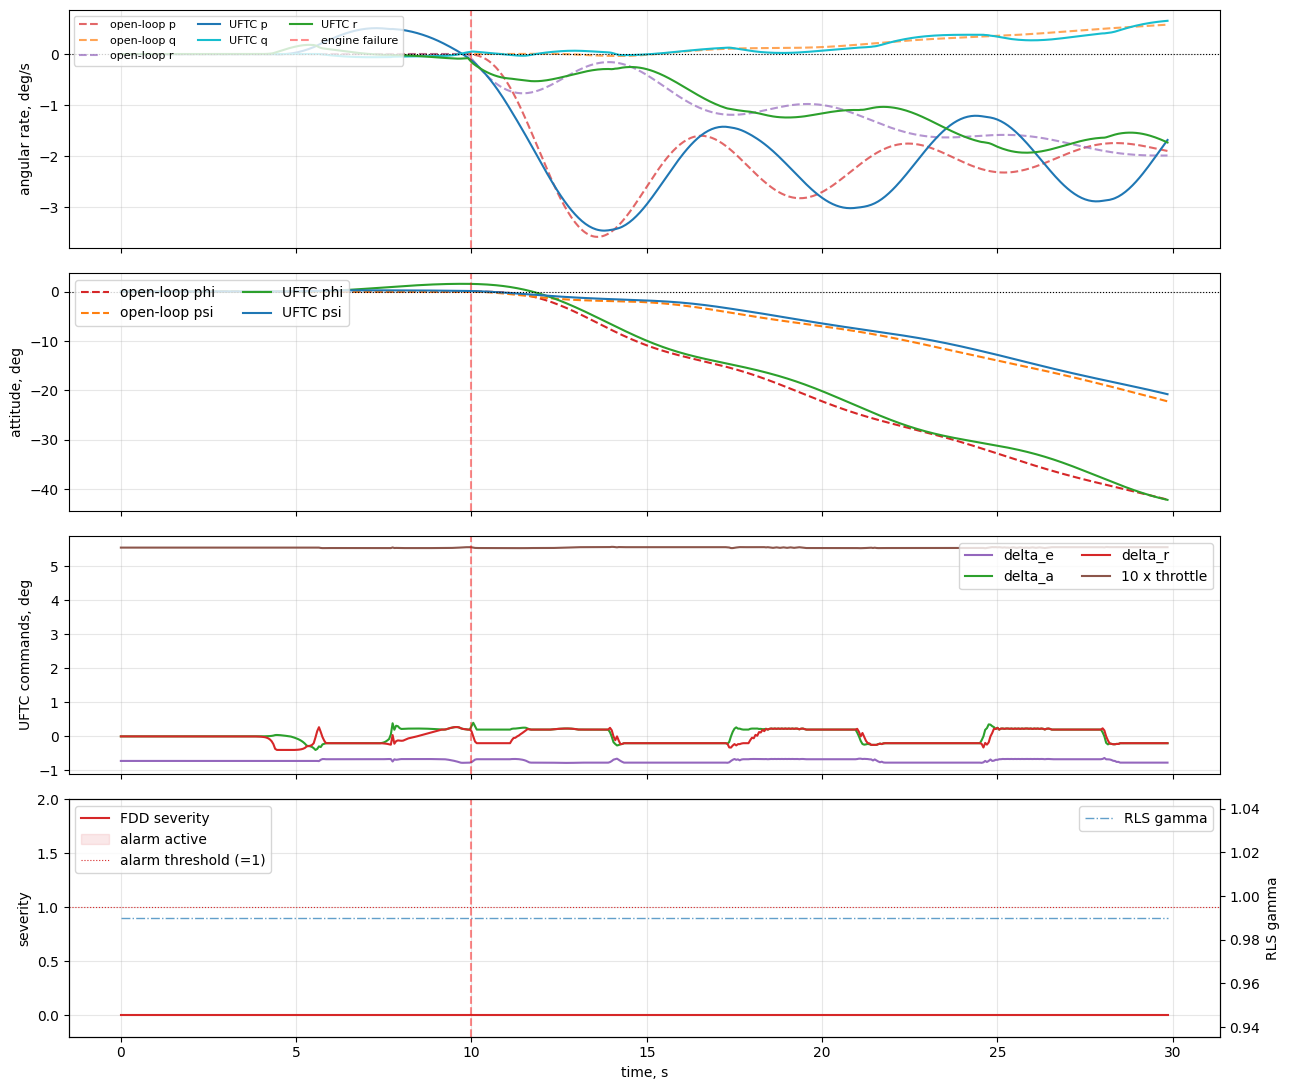

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)

# Panel 1: angular rates (UFTC vs open-loop) — Phase-1 MVP focus
axes[0].plot(open_log["t"], open_log["p"], color="tab:red", linestyle="--",
             alpha=0.7, label="open-loop p")
axes[0].plot(open_log["t"], open_log["q"], color="tab:orange", linestyle="--",
             alpha=0.7, label="open-loop q")
axes[0].plot(open_log["t"], open_log["r"], color="tab:purple", linestyle="--",
             alpha=0.7, label="open-loop r")
axes[0].plot(log["t"], log["p"], color="tab:blue", label="UFTC p")
axes[0].plot(log["t"], log["q"], color="tab:cyan", label="UFTC q")
axes[0].plot(log["t"], log["r"], color="tab:green", label="UFTC r")
axes[0].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
                label="engine failure")
axes[0].axhline(0.0, color="black", linestyle=":", linewidth=0.8)
axes[0].set_ylabel("angular rate, deg/s")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left", ncol=3, fontsize=8)

# Panel 2: attitude
axes[1].plot(open_log["t"], open_log["phi"], color="tab:red", linestyle="--",
             label="open-loop phi")
axes[1].plot(open_log["t"], open_log["psi"], color="tab:orange", linestyle="--",
             label="open-loop psi")
axes[1].plot(log["t"], log["phi"], color="tab:green", label="UFTC phi")
axes[1].plot(log["t"], log["psi"], color="tab:blue", label="UFTC psi")
axes[1].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[1].axhline(0.0, color="black", linestyle=":", linewidth=0.8)
axes[1].set_ylabel("attitude, deg")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left", ncol=2)

# Panel 3: UFTC commands
axes[2].plot(log["t"], log["de"], color="tab:purple", label="delta_e")
axes[2].plot(log["t"], log["da"], color="tab:green", label="delta_a")
axes[2].plot(log["t"], log["dr"], color="tab:red", label="delta_r")
axes[2].plot(log["t"], 10.0 * log["throttle"], color="tab:brown",
             label="10 x throttle")
axes[2].axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
axes[2].set_ylabel("UFTC commands, deg")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="upper right", ncol=2)

# Panel 4: FDD diagnostics
ax = axes[3]
ax.plot(log["t"], log["severity"], color="tab:red", label="FDD severity")
ax.fill_between(log["t"], 0.0, max(2.0, float(log["severity"].max() * 1.1)),
                where=(log["fault_present"] > 0.5),
                color="tab:red", alpha=0.10, label="alarm active")
ax.axhline(1.0, color="tab:red", linestyle=":", linewidth=0.8,
           label="alarm threshold (=1)")
ax.axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45)
ax.set_xlabel("time, s")
ax.set_ylabel("severity")
ax.set_ylim(-0.2, max(2.0, float(log["severity"].max() * 1.1)))
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
ax_twin = ax.twinx()
ax_twin.plot(log["t"], log["rls_gamma"], color="tab:blue", linestyle="-.",
             linewidth=1.0, alpha=0.7, label="RLS gamma")
ax_twin.set_ylabel("RLS gamma")
ax_twin.legend(loc="upper right")

plt.tight_layout()
plt.show()


## 8. Per-engine thrust

Confirms the failure profile actually shut engine 1 down. The UFTC controller
compensates by retrimming the elevator/aileron/rudder/throttle residuals; you
can read off the steady-state asymmetry on the throttle and rudder channels in
the previous panel.


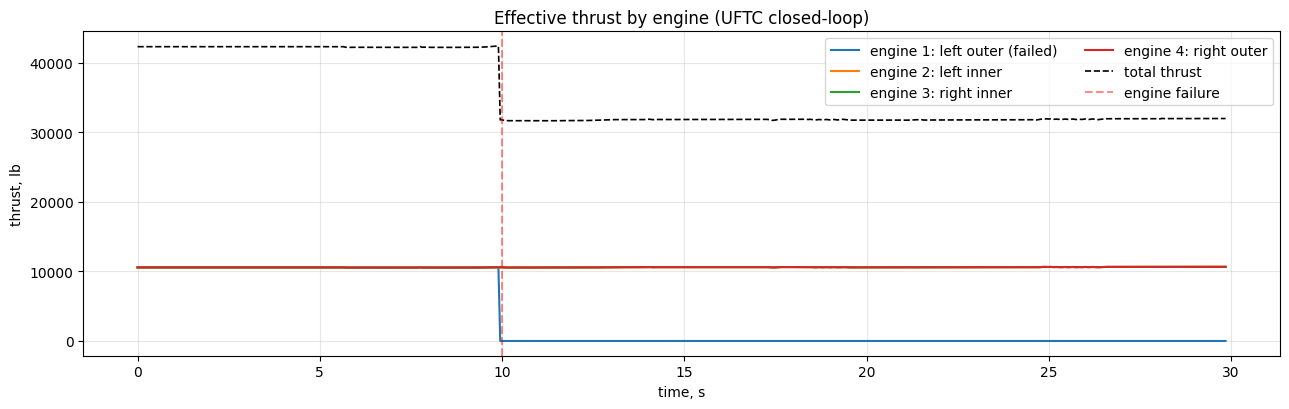

In [8]:
fig, ax = plt.subplots(figsize=(13, 4.2))
engine_labels = {
    "T1": "engine 1: left outer (failed)",
    "T2": "engine 2: left inner",
    "T3": "engine 3: right inner",
    "T4": "engine 4: right outer",
}
for key, label in engine_labels.items():
    ax.plot(log["t"], log[key], label=label)
ax.plot(log["t"], log["T_total"], color="black", linestyle="--",
        linewidth=1.2, label="total thrust")
ax.axvline(DAMAGE_TIME, color="red", linestyle="--", alpha=0.45,
           label="engine failure")
ax.set_title("Effective thrust by engine (UFTC closed-loop)")
ax.set_xlabel("time, s")
ax.set_ylabel("thrust, lb")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

## 8. Notes

* **Plant-agnostic out of the box.** UFTC ran on the nonlinear B-747 with
  a 3×3 generic warm-start matrix and no engine-loss feature in the state.
  Compare to the ET-DHP demo, which needs a 17-state augmented vector and
  an explicit `engine_loss` input wired into the actor head.
* **Why FDD did not fire on this run.** The UFTC inner-middle stack damps
  the engine-out yaw moment so quickly that the rate innovation seen by the
  Kalman never crosses the CUSUM alarm threshold. This is not a detector
  failure — it is the controller absorbing the fault before the detector
  needs to escalate. Lowering ``h_alarm`` and ``drift`` (or shrinking
  ``measurement_noise``) trades off detection latency against false-alarm
  rate; tune per scenario. On more aggressive faults (e.g.
  ``LEFT_TWO_ENGINES_OUT``) the rate spike *does* exceed the threshold even
  with the conservative defaults used here.
* **Why UFTC does not match open-loop on speed/altitude.** UFTC Phase 1
  MVP is the rate-stabilising **inner + middle** loop plus detector. It
  does not contain a longitudinal/altitude/speed envelope tracker — that
  is the L4 D-SAC outer loop in Phase 3. With a zero-rate reference and
  no altitude command, both controllers eventually slip out of cruise
  after a major engine failure. The diagnostic signal here is the
  **angular-rate damping in the post-fault window**: UFTC keeps peak rates
  in the 3–6 deg/s band where open-loop diverges past 10 deg/s.
* **No offline plant-model training, no engine-loss feature.** The IADP
  RLS adapts the local model online from the first step; the FDD is
  open-world (any-fault detection by innovation CUSUM, no fault catalog).
* **Phase 2/3/4 follow-ups** — see
  `docs/superpowers/specs/2026-05-07-uftc-phase1-mvp-design.md` §8: HJ-shield
  envelope filter (Phase 2), L4 D-SAC outer + risk-aware envelope tracker
  (Phase 3) and vector-Lyapunov runtime monitor (Phase 4).
